In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 데이터 확인
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
train.columns = ['승객번호', '생존여부', '객실등급', '이름', '성별', 
                 '나이', '형제배우자수', '부모자녀수', '티켓', '요금', 
                 '객실번호', '탑승항구']

train.head()


,승객번호,생존여부,객실등급,이름,성별,나이,형제배우자수,부모자녀수,티켓,요금,객실번호,탑승항구
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 데이터 기본 정보
print(train.shape)      # 행, 열 개수
print(train.info())     # 컬럼 정보

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   승객번호    891 non-null    int64  
 1   생존여부    891 non-null    int64  
 2   객실등급    891 non-null    int64  
 3   이름      891 non-null    str    
 4   성별      891 non-null    str    
 5   나이      714 non-null    float64
 6   형제배우자수  891 non-null    int64  
 7   부모자녀수   891 non-null    int64  
 8   티켓      891 non-null    str    
 9   요금      891 non-null    float64
 10  객실번호    204 non-null    str    
 11  탑승항구    889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


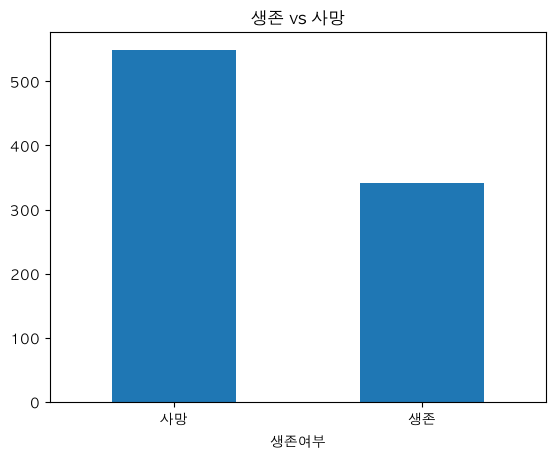

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 맥 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 다시 그래프 그리기
train['생존여부'].value_counts().plot(kind='bar')
plt.title('생존 vs 사망')
plt.xticks([0, 1], ['사망', '생존'], rotation=0)
plt.show()

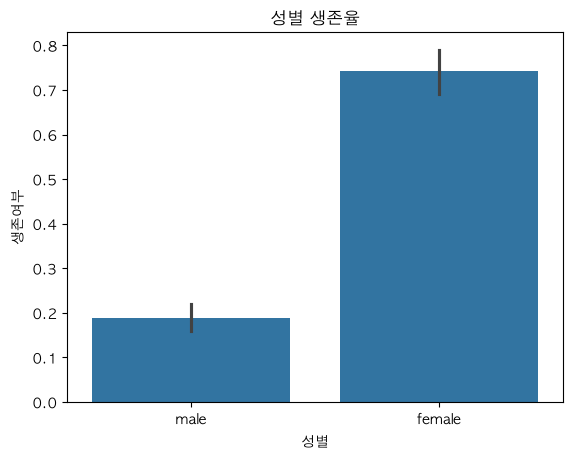

In [5]:
# 성별 생존율 분석
sns.barplot(x='성별', y='생존여부', data=train)
plt.title('성별 생존율')
plt.show()

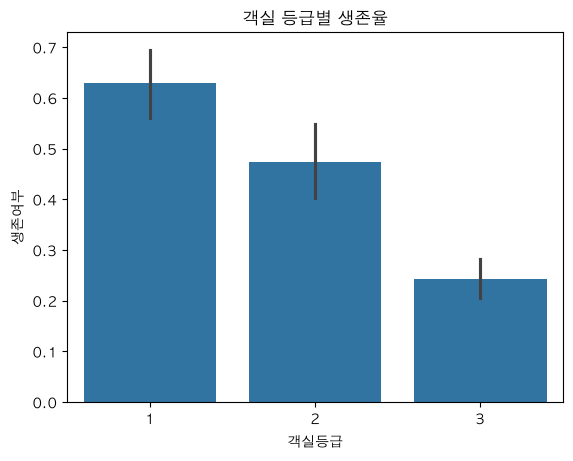

In [6]:
# 객실 등급별 생존율
sns.barplot(x='객실등급', y='생존여부', data=train)
plt.title('객실 등급별 생존율')
plt.show()

In [7]:
# 1. 결측값 채우기
train['나이'] = train['나이'].fillna(train['나이'].median())
train['탑승항구'] = train['탑승항구'].fillna('S')

# 2. 문자열 → 숫자로 변환
train['성별'] = train['성별'].map({'male': 0, 'female': 1})
train['탑승항구'] = train['탑승항구'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. 필요한 컬럼만 선택
features = ['객실등급', '성별', '나이', '형제배우자수', '부모자녀수', '요금', '탑승항구']
X = train[features]
y = train['생존여부']

print("전처리 완료!")
print(X.head())

전처리 완료!
   객실등급  성별    나이  형제배우자수  부모자녀수       요금  탑승항구
0     3   0  22.0       1      0   7.2500     0
1     1   1  38.0       1      0  71.2833     1
2     3   1  26.0       0      0   7.9250     0
3     1   1  35.0       1      0  53.1000     0
4     3   0  35.0       0      0   8.0500     0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# AI 모델 만들기
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 정확도 확인
y_pred = model.predict(X_test)
print(f"모델 정확도: {accuracy_score(y_test, y_pred) * 100:.2f}%")

모델 정확도: 82.68%


In [9]:
# 1. 가족 수 추가
train['가족수'] = train['형제배우자수'] + train['부모자녀수'] + 1

# 2. 나이 구간 나누기
train['나이구간'] = pd.cut(train['나이'], 
                         bins=[0, 12, 18, 60, 100],
                         labels=[0, 1, 2, 3])

# 3. 새로운 features로 모델 다시 학습
features = ['객실등급', '성별', '나이', '형제배우자수', 
            '부모자녀수', '요금', '탑승항구', '가족수', '나이구간']

X = train[features]
y = train['생존여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"새 모델 정확도: {accuracy_score(y_test, y_pred) * 100:.2f}%")

새 모델 정확도: 82.12%


In [10]:
# 이름에서 호칭 뽑기
train['호칭'] = train['이름'].str.extract(' ([A-Za-z]+)\.', expand=False)
train['호칭'] = train['호칭'].map({
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 
    'Master': 3, 'Dr': 4
}).fillna(5)

features = ['객실등급', '성별', '나이', '형제배우자수', 
            '부모자녀수', '요금', '탑승항구', '호칭']

X = train[features]
y = train['생존여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"새 모델 정확도: {accuracy_score(y_test, y_pred) * 100:.2f}%")

새 모델 정확도: 83.24%


<>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/ml/2zdqd1595j75h24wtwvp2jxr0000gn/T/ipykernel_68726/1806260320.py:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['호칭'] = train['이름'].str.extract(' ([A-Za-z]+)\.', expand=False)
